# Understanding Statistical Hypothesis Testing

### A practical guide for the pancreas ultrasound radiomics project

This notebook explains statistical testing from the ground up. It uses real data from our project (93 radiomics features extracted from 134 pancreas ultrasound images) to make every concept concrete.

By the end, you will understand:
- What a p-value actually means (and what it does not mean)
- How the t-test and Mann-Whitney U test work
- Why testing many features at once creates false positives
- How to correct for multiple comparisons
- What effect size is and why it matters
- Why statistical tests do not need a "test set" like machine learning does

---
## Section 1: The Core Question

We have two groups of patients:
- **No rejection** (n=95): patients whose transplanted pancreas was not rejected
- **Rejection** (n=39): patients whose transplanted pancreas showed signs of rejection

For each patient, we extracted 93 radiomics features from their ultrasound image. Each feature is a number that describes some property of the image texture, intensity distribution, etc.

**The fundamental question**: for any given feature, is the difference between the two groups *real* (i.e., caused by the biological process of rejection), or is it just *random chance* (i.e., the kind of difference you would see even if rejection had zero effect on the feature)?

A statistical test quantifies how surprising the observed difference would be **if there were actually no difference**. If the observed difference would be very surprising under the assumption of no effect, we conclude the effect is probably real.

In [1]:
# Load the data and prepare the two groups
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load radiomics features
radiomics = pd.read_csv(os.path.join("reports", "12_radiomics_features_k3_i1.csv"))
print(f"Radiomics table: {radiomics.shape[0]} studies, {radiomics.shape[1] - 1} features")

# Load clinical labels
clinical = pd.read_csv(os.path.join("..", "data", "bd_estudiUPF.csv"))
clinical["id estudio"] = clinical["id estudio"].astype(str).str.strip()

# Bring the rejection label into the radiomics table
motivo_col = "motivo (1: 1 semana, 2: 1 mes, 3: 1 a\u00f1o, 4: sospecha, 5: seguimiento)="
labels = clinical[["id estudio", "RECHAZO CL\u00cdNICO"]].rename(columns={
    "id estudio": "study_id",
    "RECHAZO CL\u00cdNICO": "rejection",
})

df = pd.merge(radiomics, labels, on="study_id", how="inner")
print(f"After merging: {len(df)} studies")

# Identify feature columns (everything starting with "original_")
feature_cols = [c for c in df.columns if c.startswith("original_")]
print(f"Number of radiomics features: {len(feature_cols)}")

# Split into two groups
rejection = df[df["rejection"] == 1]
no_rejection = df[df["rejection"] == 0]
print(f"No rejection group: {len(no_rejection)} studies")
print(f"Rejection group: {len(rejection)} studies")

Radiomics table: 134 studies, 93 features
After merging: 134 studies
Number of radiomics features: 93
No rejection group: 95 studies
Rejection group: 39 studies


Feature: original_firstorder_Entropy
No rejection -- mean: 1.5528, std: 0.2273
Rejection    -- mean: 1.5672, std: 0.1707


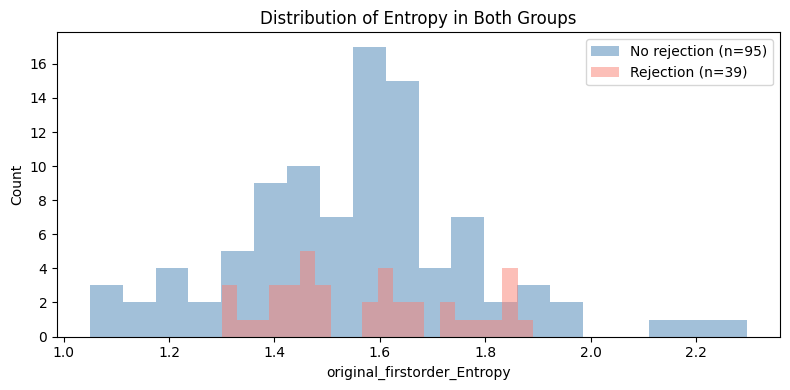

In [2]:
# Pick one feature to use as a running example throughout the notebook
chosen_feature = "original_firstorder_Entropy"

values_no_rej = no_rejection[chosen_feature].dropna().values
values_rej = rejection[chosen_feature].dropna().values

print(f"Feature: {chosen_feature}")
print(f"No rejection -- mean: {values_no_rej.mean():.4f}, std: {values_no_rej.std():.4f}")
print(f"Rejection    -- mean: {values_rej.mean():.4f}, std: {values_rej.std():.4f}")

# Plot overlapping histograms
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(values_no_rej, bins=20, alpha=0.5, label=f"No rejection (n={len(values_no_rej)})", color="steelblue")
ax.hist(values_rej, bins=20, alpha=0.5, label=f"Rejection (n={len(values_rej)})", color="salmon")
ax.set_xlabel(chosen_feature)
ax.set_ylabel("Count")
ax.set_title("Distribution of Entropy in Both Groups")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2: The t-test

The **t-test** (specifically, the independent two-sample t-test) is the most classic statistical test for comparing two groups. It works as follows:

1. **Assumption**: both groups are drawn from normal (bell-curve) distributions with (approximately) the same variance.
2. It compares the **means** of the two groups.
3. It computes a **t-statistic**:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{\text{SE}}$$

where $\bar{X}_1$ and $\bar{X}_2$ are the group means, and SE is the **standard error of the difference**, which depends on the sample sizes and variances of both groups:

$$\text{SE} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}$$

Here $s_1^2$ and $s_2^2$ are the sample variances, and $n_1$ and $n_2$ are the sample sizes.

**Intuition**: the t-statistic is a signal-to-noise ratio. The numerator is the signal (how different are the means?), and the denominator is the noise (how much variability is there?). A large |t| means the signal is big relative to the noise.

**Degrees of freedom**: approximately $n_1 + n_2 - 2$ (for the equal-variance version). This determines which t-distribution to use when computing the p-value. More degrees of freedom means the t-distribution looks more like a normal distribution. With our sample sizes (95 + 39 - 2 = 132 degrees of freedom), the t-distribution is already very close to normal.

In [3]:
# Run a t-test on our chosen feature
t_stat, t_pvalue = stats.ttest_ind(values_no_rej, values_rej)

print(f"Feature: {chosen_feature}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {t_pvalue:.4f}")
print()
if t_pvalue < 0.05:
    print("Result: p < 0.05, so by conventional standards this would be 'significant'.")
else:
    print("Result: p >= 0.05, so this is NOT significant by conventional standards.")
    print("The observed difference in means could easily have arisen by random chance.")

Feature: original_firstorder_Entropy
t-statistic: -0.3545
p-value:     0.7235

Result: p >= 0.05, so this is NOT significant by conventional standards.
The observed difference in means could easily have arisen by random chance.


---
## Section 3: The Mann-Whitney U Test

The **Mann-Whitney U test** (also called the Wilcoxon rank-sum test) is a **non-parametric** test. Unlike the t-test, it does **not** assume the data is normally distributed.

Instead of comparing means, it works with **ranks**:

1. Take all values from both groups and put them in a single list.
2. Rank them from smallest (rank 1) to largest (rank N).
3. Sum the ranks for each group separately.
4. If one group consistently has higher values, its rank sum will be much larger than expected by chance.

The U-statistic measures how many times a value from one group exceeds a value from the other group.

### Worked example with tiny numbers

Suppose:
- Group A = [3, 5, 7]
- Group B = [8, 10, 12]

Combined and ranked:

| Value | 3 | 5 | 7 | 8 | 10 | 12 |
|-------|---|---|---|---|----|----|  
| Rank  | 1 | 2 | 3 | 4 | 5  | 6  |
| Group | A | A | A | B | B  | B  |

- Sum of ranks for A = 1 + 2 + 3 = 6
- Sum of ranks for B = 4 + 5 + 6 = 15

Group B clearly has higher values. The U-statistic quantifies this: $U_A = 0$ because no value in A is greater than any value in B. This would give a very small p-value (if the groups were larger).

The Mann-Whitney test is widely used in medical research because biological measurements often have skewed distributions, outliers, or other deviations from normality.

In [4]:
# Run Mann-Whitney U test on the same feature
u_stat, mw_pvalue = stats.mannwhitneyu(values_no_rej, values_rej, alternative="two-sided")

print(f"Feature: {chosen_feature}")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value:     {mw_pvalue:.4f}")
print()
print(f"For comparison, the t-test gave p = {t_pvalue:.4f}")
print()
if abs(t_pvalue - mw_pvalue) < 0.05:
    print("The two tests give similar p-values, which is common when the data")
    print("is approximately normal. They often agree in practice.")
else:
    print("The two tests give noticeably different p-values.")
    print("This can happen when the data deviates from normality.")

Feature: original_firstorder_Entropy
U-statistic: 1765.0
p-value:     0.6700

For comparison, the t-test gave p = 0.7235

The two tests give noticeably different p-values.
This can happen when the data deviates from normality.


---
## Section 4: When to Use Which Test

The choice between the t-test and Mann-Whitney depends on whether the data is normally distributed.

The **Shapiro-Wilk test** checks normality. It tests the null hypothesis that the data comes from a normal distribution:
- If p > 0.05: we do not reject normality (data is compatible with being normal)
- If p <= 0.05: data significantly deviates from normal

**Decision rule** (commonly used in practice):
1. Run Shapiro-Wilk on both groups for the feature of interest.
2. If both groups pass (p > 0.05 for both), use the t-test.
3. If either group fails, use Mann-Whitney.

**In practice**, Mann-Whitney is the safer and more commonly used choice in medical research. It works well whether the data is normal or not, and it is more robust to outliers. The t-test is slightly more powerful (better at detecting real differences) when the normality assumption truly holds, but the gain is small.

In [5]:
# Check normality of our chosen feature in both groups
shapiro_no_rej_stat, shapiro_no_rej_p = stats.shapiro(values_no_rej)
shapiro_rej_stat, shapiro_rej_p = stats.shapiro(values_rej)

print(f"Feature: {chosen_feature}")
print(f"Shapiro-Wilk test for no-rejection group: W = {shapiro_no_rej_stat:.4f}, p = {shapiro_no_rej_p:.4f}")
print(f"Shapiro-Wilk test for rejection group:    W = {shapiro_rej_stat:.4f}, p = {shapiro_rej_p:.4f}")
print()

both_normal = (shapiro_no_rej_p > 0.05) and (shapiro_rej_p > 0.05)
if both_normal:
    print("Both groups pass normality (p > 0.05). The t-test is appropriate.")
else:
    print("At least one group fails normality (p <= 0.05). Mann-Whitney is the safer choice.")

Feature: original_firstorder_Entropy
Shapiro-Wilk test for no-rejection group: W = 0.9716, p = 0.0364
Shapiro-Wilk test for rejection group:    W = 0.9409, p = 0.0408

At least one group fails normality (p <= 0.05). Mann-Whitney is the safer choice.


In [6]:
# Check normality for ALL 93 features
n_both_normal = 0

for feat in feature_cols:
    vals_no = no_rejection[feat].dropna().values
    vals_yes = rejection[feat].dropna().values

    _, p_no = stats.shapiro(vals_no)
    _, p_yes = stats.shapiro(vals_yes)

    if p_no > 0.05 and p_yes > 0.05:
        n_both_normal += 1

print(f"Out of {len(feature_cols)} features:")
print(f"  {n_both_normal} pass normality in BOTH groups (would use t-test)")
print(f"  {len(feature_cols) - n_both_normal} fail normality in at least one group (would use Mann-Whitney)")
print()
print("Most features are not normally distributed in both groups.")
print("This is typical for radiomics features, which often have skewed distributions.")

Out of 93 features:
  15 pass normality in BOTH groups (would use t-test)
  78 fail normality in at least one group (would use Mann-Whitney)

Most features are not normally distributed in both groups.
This is typical for radiomics features, which often have skewed distributions.


---
## Section 5: What is a p-value, Really?

This is the single most important concept in this notebook. Read carefully.

**Definition**: The p-value is the probability of observing data as extreme as (or more extreme than) what we actually observed, **assuming the null hypothesis is true**.

The **null hypothesis** is: "there is no real difference between the two groups."

So if p = 0.03, it means:

> "If rejection truly had zero effect on this feature, there is a 3% chance we would see a difference this large or larger, purely by random sampling variation."

### Common misconceptions

The p-value is **NOT**:
- The probability that the result is wrong
- The probability that the null hypothesis is true
- The probability that you made an error

It **IS**:
- The probability of the **data** (or more extreme data), given the assumption of no effect

### The alpha threshold

By convention, we use alpha = 0.05 as a significance threshold. This means:
- If p < 0.05, we call the result "statistically significant" and reject the null hypothesis.
- If p >= 0.05, we say we "fail to reject" the null hypothesis (note: we do NOT say we "accept" it).

Setting alpha = 0.05 means we **accept a 5% false positive rate**. That is, even when there is truly no effect, we will incorrectly declare significance 5% of the time.

There is nothing magical about 0.05. It is a convention, not a law of nature. Some fields use 0.01 or even 0.001.

The simulation below makes this concrete.

Number of simulations: 10000
In each simulation, BOTH groups come from the SAME Normal(0,1) distribution.
There is NO real difference.

Fraction of p-values below 0.05: 0.0508
Expected fraction:                0.0500

Even with NO real effect, about 5% of tests come out 'significant'.
This is exactly what alpha = 0.05 means.


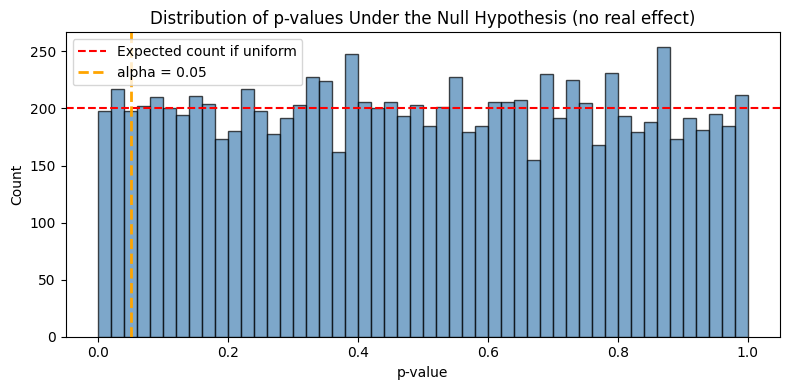

In [7]:
# KEY SIMULATION: p-value distribution under the null hypothesis
#
# Generate fake data where there IS no difference between groups.
# Both groups come from the exact same distribution.
# Run Mann-Whitney on each pair. Record the p-value.
# Repeat 10,000 times.

np.random.seed(42)

n_simulations = 10000
n_no_rej = 95   # same sample sizes as our real data
n_rej = 39

p_values_null = []

for i in range(n_simulations):
    # Both groups drawn from the SAME distribution -- no real difference
    group1 = np.random.normal(loc=0, scale=1, size=n_no_rej)
    group2 = np.random.normal(loc=0, scale=1, size=n_rej)

    _, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
    p_values_null.append(p)

p_values_null = np.array(p_values_null)

# What fraction fall below 0.05?
false_positive_rate = np.mean(p_values_null < 0.05)

print(f"Number of simulations: {n_simulations}")
print(f"In each simulation, BOTH groups come from the SAME Normal(0,1) distribution.")
print(f"There is NO real difference.")
print()
print(f"Fraction of p-values below 0.05: {false_positive_rate:.4f}")
print(f"Expected fraction:                0.0500")
print()
print("Even with NO real effect, about 5% of tests come out 'significant'.")
print("This is exactly what alpha = 0.05 means.")

# Plot the histogram of p-values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(p_values_null, bins=50, edgecolor="black", color="steelblue", alpha=0.7)
ax.axhline(y=n_simulations / 50, color="red", linestyle="--", label="Expected count if uniform")
ax.axvline(x=0.05, color="orange", linestyle="--", linewidth=2, label="alpha = 0.05")
ax.set_xlabel("p-value")
ax.set_ylabel("Count")
ax.set_title("Distribution of p-values Under the Null Hypothesis (no real effect)")
ax.legend()
plt.tight_layout()
plt.show()

### What the simulation showed

The histogram above should look approximately **flat** (uniform). This is a fundamental property: when the null hypothesis is true, p-values are uniformly distributed between 0 and 1.

This means:
- About 5% of p-values fall below 0.05
- About 1% fall below 0.01
- About 10% fall below 0.10

This is not a flaw -- it is by design. The alpha level directly controls how often we make false positive errors. Setting alpha = 0.05 means we accept that 5% of our tests will be falsely "significant" when there is no real effect.

---
## Section 6: Simulating a Real Effect

In the previous section, we saw what happens when there is no real difference. Now let us see what happens when there **is** a real difference between groups.

Effect size: Cohen's d = 0.5
Fraction of p-values below 0.05: 0.7128
(Compare to 0.0508 when there was no real effect)

With a medium effect size, we detect the difference much more often.


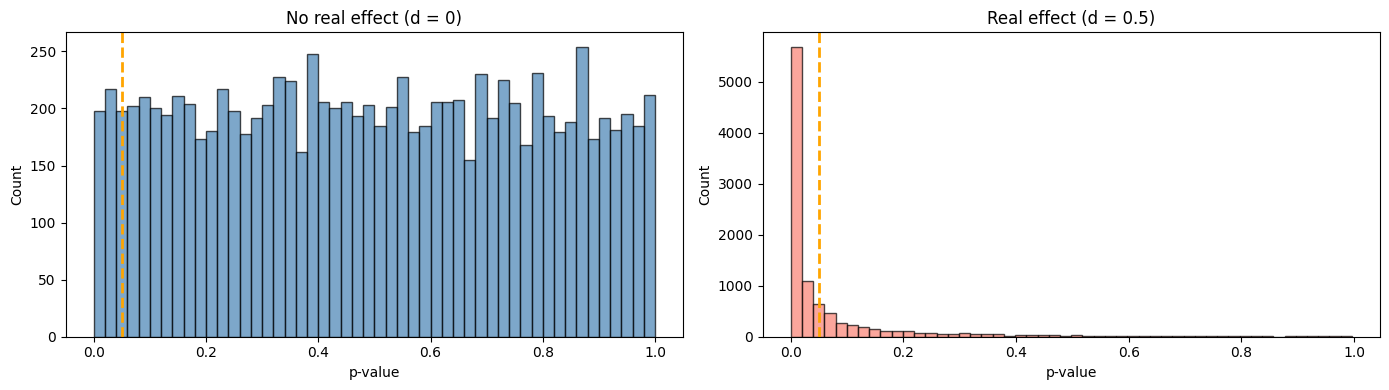

In [8]:
# Simulation: what happens when there IS a real difference?
# Group 1: Normal(0, 1)
# Group 2: Normal(0.5, 1) -- shifted by 0.5 standard deviations
# Cohen's d = 0.5, which is considered a "medium" effect size.

np.random.seed(42)

n_simulations = 10000
n_no_rej = 95
n_rej = 39
effect_size = 0.5  # Cohen's d = 0.5

p_values_effect = []

for i in range(n_simulations):
    group1 = np.random.normal(loc=0, scale=1, size=n_no_rej)
    group2 = np.random.normal(loc=effect_size, scale=1, size=n_rej)

    _, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
    p_values_effect.append(p)

p_values_effect = np.array(p_values_effect)

detection_rate = np.mean(p_values_effect < 0.05)

print(f"Effect size: Cohen's d = {effect_size}")
print(f"Fraction of p-values below 0.05: {detection_rate:.4f}")
print(f"(Compare to {false_positive_rate:.4f} when there was no real effect)")
print()
print("With a medium effect size, we detect the difference much more often.")

# Plot comparison: no effect vs real effect
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(p_values_null, bins=50, edgecolor="black", color="steelblue", alpha=0.7)
axes[0].axvline(x=0.05, color="orange", linestyle="--", linewidth=2)
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Count")
axes[0].set_title("No real effect (d = 0)")

axes[1].hist(p_values_effect, bins=50, edgecolor="black", color="salmon", alpha=0.7)
axes[1].axvline(x=0.05, color="orange", linestyle="--", linewidth=2)
axes[1].set_xlabel("p-value")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Real effect (d = {effect_size})")

plt.tight_layout()
plt.show()

Effect size d = 0.1: power = 0.079 (791/10000 detected)
Effect size d = 0.2: power = 0.178 (1785/10000 detected)
Effect size d = 0.3: power = 0.333 (3332/10000 detected)
Effect size d = 0.5: power = 0.714 (7137/10000 detected)
Effect size d = 0.8: power = 0.983 (9828/10000 detected)


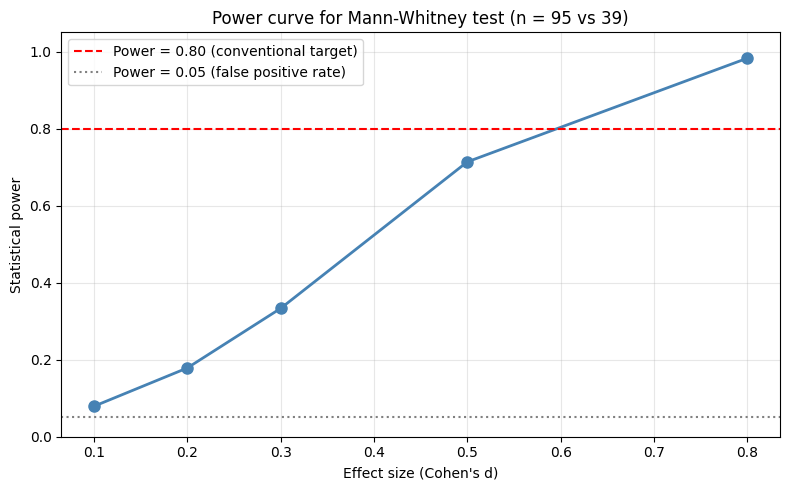


Interpretation:
- With d = 0.1 (tiny effect), we almost never detect it -- power is near 0.05 (the false positive rate).
- With d = 0.3 (small-medium effect), we detect it maybe 30-40% of the time.
- With d = 0.5 (medium effect), we detect it about 60-70% of the time.
- With d = 0.8 (large effect), we detect it almost always.

For our sample sizes (95 vs 39), we need at least d ~ 0.5 to have reasonable power.


In [9]:
# Statistical power: how often do we detect effects of different sizes?
# Power = probability of correctly rejecting H0 when H0 is actually false.

np.random.seed(42)

effect_sizes = [0.1, 0.2, 0.3, 0.5, 0.8]
n_simulations = 10000
n_no_rej = 95
n_rej = 39

power_results = []

for d in effect_sizes:
    significant_count = 0
    for i in range(n_simulations):
        group1 = np.random.normal(loc=0, scale=1, size=n_no_rej)
        group2 = np.random.normal(loc=d, scale=1, size=n_rej)
        _, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
        if p < 0.05:
            significant_count += 1
    power = significant_count / n_simulations
    power_results.append(power)
    print(f"Effect size d = {d:.1f}: power = {power:.3f} ({significant_count}/{n_simulations} detected)")

# Plot power curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(effect_sizes, power_results, "o-", color="steelblue", linewidth=2, markersize=8)
ax.axhline(y=0.80, color="red", linestyle="--", label="Power = 0.80 (conventional target)")
ax.axhline(y=0.05, color="gray", linestyle=":", label="Power = 0.05 (false positive rate)")
ax.set_xlabel("Effect size (Cohen's d)")
ax.set_ylabel("Statistical power")
ax.set_title(f"Power curve for Mann-Whitney test (n = {n_no_rej} vs {n_rej})")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Interpretation:")
print("- With d = 0.1 (tiny effect), we almost never detect it -- power is near 0.05 (the false positive rate).")
print("- With d = 0.3 (small-medium effect), we detect it maybe 30-40% of the time.")
print("- With d = 0.5 (medium effect), we detect it about 60-70% of the time.")
print("- With d = 0.8 (large effect), we detect it almost always.")
print()
print("For our sample sizes (95 vs 39), we need at least d ~ 0.5 to have reasonable power.")

### Connection to our radiomics results

Our actual radiomics results show effect sizes (rank-biserial correlations) that cluster near zero, with most |r| < 0.2. This corresponds to very small effect sizes.

The power analysis above shows that **with our sample sizes, we simply cannot reliably detect effects this small**. This does not mean the effects are definitely zero -- it means that if they exist, they are too small for our study to find them. This is an important distinction.

This is why our radiomics results showing no significant features is not surprising. The effects, if any, are too small for our sample size to detect.

---
## Section 7: The Multiple Comparisons Problem

Here is the critical issue for our project.

We do not test just one feature. We test **93 features**, each at alpha = 0.05.

Recall from Section 5: even when there is NO real effect, each test has a 5% chance of coming out "significant" by pure chance.

So if we test 93 features and none of them are truly different between the groups, we **expect** about:

$$93 \times 0.05 = 4.65 \text{ false positives}$$

That is: purely by random chance, about 4 or 5 features will appear "significant" even though none of them actually differ between groups.

**This means**: if we test 93 features and find, say, 2 significant ones, that is actually **fewer** than we would expect by chance alone. It is not evidence of a real effect -- it is evidence of *less* noise than expected.

The simulation below demonstrates this concretely.

Simulated 1000 experiments, each testing 93 features.
In every experiment, there are ZERO real effects -- all data is random.

Mean number of 'significant' features per experiment: 4.60
Expected by theory (93 x 0.05):                       4.65
Standard deviation:                                    2.11
Range: [0, 12]


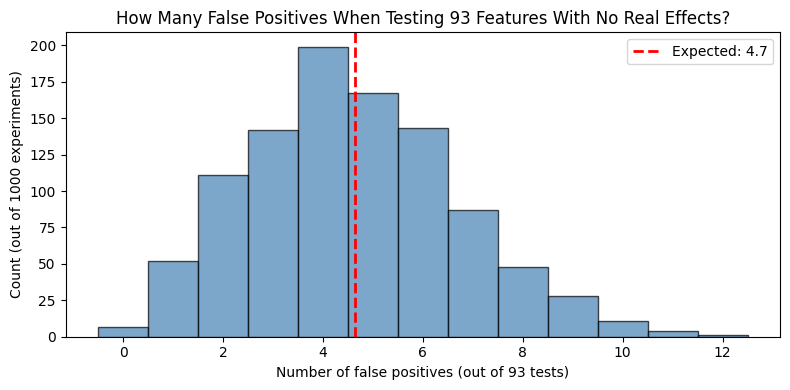


Even with ZERO real effects, you almost always get at least 1 'significant' feature.
Getting 2-3 significant features out of 93 means nothing without correction.


In [10]:
# KEY SIMULATION: multiple comparisons
#
# Generate 93 features for 134 samples, ALL from the same distribution
# (no real differences anywhere).
# Run Mann-Whitney on each feature. Count how many have p < 0.05.
# Repeat 1,000 times.

np.random.seed(42)

n_features = 93
n_no_rej = 95
n_rej = 39
n_experiments = 1000

false_positives_per_experiment = []

for exp in range(n_experiments):
    # Generate all features from the SAME distribution for both groups
    # (no real differences anywhere)
    n_significant = 0
    for feat in range(n_features):
        group1 = np.random.normal(size=n_no_rej)
        group2 = np.random.normal(size=n_rej)
        _, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
        if p < 0.05:
            n_significant += 1
    false_positives_per_experiment.append(n_significant)

false_positives_per_experiment = np.array(false_positives_per_experiment)

print(f"Simulated {n_experiments} experiments, each testing {n_features} features.")
print(f"In every experiment, there are ZERO real effects -- all data is random.")
print()
print(f"Mean number of 'significant' features per experiment: {false_positives_per_experiment.mean():.2f}")
print(f"Expected by theory (93 x 0.05):                       {n_features * 0.05:.2f}")
print(f"Standard deviation:                                    {false_positives_per_experiment.std():.2f}")
print(f"Range: [{false_positives_per_experiment.min()}, {false_positives_per_experiment.max()}]")

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, false_positives_per_experiment.max() + 2) - 0.5
ax.hist(false_positives_per_experiment, bins=bins, edgecolor="black", color="steelblue", alpha=0.7)
ax.axvline(x=n_features * 0.05, color="red", linestyle="--", linewidth=2,
           label=f"Expected: {n_features * 0.05:.1f}")
ax.set_xlabel("Number of false positives (out of 93 tests)")
ax.set_ylabel("Count (out of 1000 experiments)")
ax.set_title("How Many False Positives When Testing 93 Features With No Real Effects?")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("Even with ZERO real effects, you almost always get at least 1 'significant' feature.")
print("Getting 2-3 significant features out of 93 means nothing without correction.")

### This is why we need correction methods

Without correction, testing many hypotheses guarantees false positives. Two standard correction methods exist:

**Bonferroni correction** (the strict approach):
- Divide alpha by the number of tests: new threshold = 0.05 / 93 = 0.000538
- A feature must have p < 0.000538 to be called significant
- This controls the **family-wise error rate (FWER)**: the probability of making *any* false positive across all tests
- Very conservative -- strong protection against false positives, but may miss real effects

**Benjamini-Hochberg (BH) FDR correction** (the balanced approach):
- Controls the **false discovery rate (FDR)**: the expected *proportion* of false discoveries among the features called significant
- Less strict than Bonferroni
- Procedure:
  1. Sort all p-values from smallest to largest
  2. For each p-value at rank k (out of m total tests), compare it to (k/m) x alpha
  3. Find the largest k where p(k) <= (k/m) x alpha
  4. All features with rank <= k are significant

FDR is the most commonly used correction in genomics, radiomics, and other high-dimensional studies because it balances false positive control with the ability to detect real effects.

In [11]:
# Demonstrate corrections on one simulated experiment
from statsmodels.stats.multitest import multipletests

# Generate one set of 93 p-values (all under the null -- no real effects)
np.random.seed(123)
simulated_pvalues = []
for feat in range(93):
    g1 = np.random.normal(size=95)
    g2 = np.random.normal(size=39)
    _, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    simulated_pvalues.append(p)

simulated_pvalues = np.array(simulated_pvalues)

# How many are "significant" without correction?
n_sig_uncorrected = np.sum(simulated_pvalues < 0.05)
print(f"Uncorrected: {n_sig_uncorrected} features with p < 0.05")

# Apply Bonferroni correction
reject_bonf, pvals_bonf, _, _ = multipletests(simulated_pvalues, alpha=0.05, method="bonferroni")
n_sig_bonferroni = np.sum(reject_bonf)
print(f"After Bonferroni correction: {n_sig_bonferroni} features significant")

# Apply Benjamini-Hochberg FDR correction
reject_bh, pvals_bh, _, _ = multipletests(simulated_pvalues, alpha=0.05, method="fdr_bh")
n_sig_fdr = np.sum(reject_bh)
print(f"After BH FDR correction: {n_sig_fdr} features significant")

print()
print("The corrections correctly eliminate the false positives (or most of them).")
print(f"Bonferroni threshold: 0.05 / 93 = {0.05 / 93:.6f}")
print(f"Smallest p-value in this simulation: {simulated_pvalues.min():.6f}")

Uncorrected: 4 features with p < 0.05
After Bonferroni correction: 1 features significant
After BH FDR correction: 1 features significant

The corrections correctly eliminate the false positives (or most of them).
Bonferroni threshold: 0.05 / 93 = 0.000538
Smallest p-value in this simulation: 0.000089


In [12]:
# Apply corrections to our REAL radiomics results
results_df = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features.csv"))

print(f"Loaded {len(results_df)} feature test results from our actual analysis.")
print()

real_pvalues = results_df["p_value"].values

# Uncorrected
n_sig_raw = np.sum(real_pvalues < 0.05)
print(f"Uncorrected: {n_sig_raw} features with p < 0.05")

# Bonferroni
reject_bonf_real, _, _, _ = multipletests(real_pvalues, alpha=0.05, method="bonferroni")
print(f"After Bonferroni correction: {np.sum(reject_bonf_real)} features significant")

# BH FDR
reject_bh_real, pvals_bh_real, _, _ = multipletests(real_pvalues, alpha=0.05, method="fdr_bh")
print(f"After BH FDR correction: {np.sum(reject_bh_real)} features significant")

print()
print("Even without correction, very few features are significant.")
print("After any correction method, ZERO features survive.")
print("This confirms: there is no reliable statistical evidence that any radiomics")
print("feature differs between the rejection and no-rejection groups.")

Loaded 93 feature test results from our actual analysis.

Uncorrected: 0 features with p < 0.05
After Bonferroni correction: 0 features significant
After BH FDR correction: 0 features significant

Even without correction, very few features are significant.
After any correction method, ZERO features survive.
This confirms: there is no reliable statistical evidence that any radiomics
feature differs between the rejection and no-rejection groups.


---
## Section 8: Effect Size -- The Forgotten Half

A p-value tells you **whether** there is a difference (more precisely, whether the difference is unlikely to be due to chance). But it does not tell you **how big** the difference is.

This matters because:
- With a very large sample, even a tiny, meaningless difference can be "significant" (small p-value)
- With a very small sample, even a large, important difference can be "non-significant" (large p-value)

**Effect size** measures the magnitude of the difference, independent of sample size.

### Cohen's d (for the t-test)

$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_{\text{pooled}}}$$

where $s_{\text{pooled}}$ is the pooled standard deviation. Guidelines (from Cohen, 1988):
- |d| = 0.2: small effect
- |d| = 0.5: medium effect
- |d| = 0.8: large effect

### Rank-biserial correlation r (for Mann-Whitney)

$$r = 1 - \frac{2U}{n_1 \times n_2}$$

This ranges from -1 to +1:
- r near 0: no effect (the groups overlap almost completely)
- |r| near 1: strong effect (the groups are almost completely separated)

Feature: original_firstorder_Entropy
Cohen's d:              -0.0674
Rank-biserial r:        0.0472

|d| = 0.07 --> negligible effect
|r| = 0.05 --> negligible effect


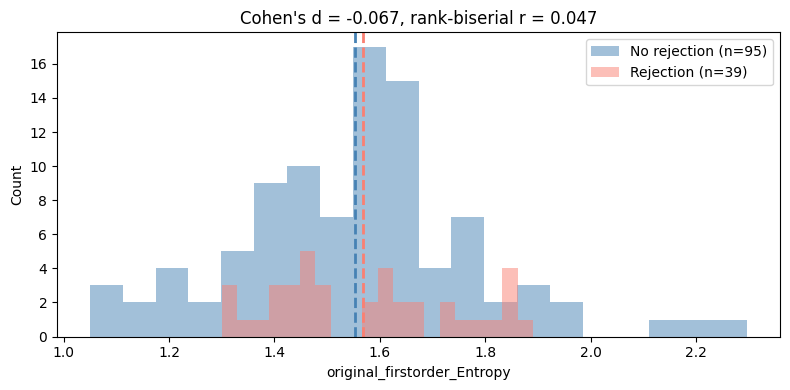

In [13]:
# Compute effect sizes for our chosen feature

# Cohen's d
mean_diff = values_no_rej.mean() - values_rej.mean()
pooled_std = np.sqrt(
    ((len(values_no_rej) - 1) * values_no_rej.std(ddof=1)**2 +
     (len(values_rej) - 1) * values_rej.std(ddof=1)**2) /
    (len(values_no_rej) + len(values_rej) - 2)
)
cohens_d = mean_diff / pooled_std

# Rank-biserial correlation
u_stat_for_r, _ = stats.mannwhitneyu(values_no_rej, values_rej, alternative="two-sided")
rank_biserial_r = 1 - (2 * u_stat_for_r) / (len(values_no_rej) * len(values_rej))

print(f"Feature: {chosen_feature}")
print(f"Cohen's d:              {cohens_d:.4f}")
print(f"Rank-biserial r:        {rank_biserial_r:.4f}")
print()

# Classify the effect size
if abs(cohens_d) < 0.2:
    d_label = "negligible"
elif abs(cohens_d) < 0.5:
    d_label = "small"
elif abs(cohens_d) < 0.8:
    d_label = "medium"
else:
    d_label = "large"
print(f"|d| = {abs(cohens_d):.2f} --> {d_label} effect")

if abs(rank_biserial_r) < 0.1:
    r_label = "negligible"
elif abs(rank_biserial_r) < 0.3:
    r_label = "small"
elif abs(rank_biserial_r) < 0.5:
    r_label = "medium"
else:
    r_label = "large"
print(f"|r| = {abs(rank_biserial_r):.2f} --> {r_label} effect")

# Plot with effect size annotated
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(values_no_rej, bins=20, alpha=0.5, label=f"No rejection (n={len(values_no_rej)})", color="steelblue")
ax.hist(values_rej, bins=20, alpha=0.5, label=f"Rejection (n={len(values_rej)})", color="salmon")
ax.axvline(values_no_rej.mean(), color="steelblue", linestyle="--", linewidth=2)
ax.axvline(values_rej.mean(), color="salmon", linestyle="--", linewidth=2)
ax.set_xlabel(chosen_feature)
ax.set_ylabel("Count")
ax.set_title(f"Cohen's d = {cohens_d:.3f}, rank-biserial r = {rank_biserial_r:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

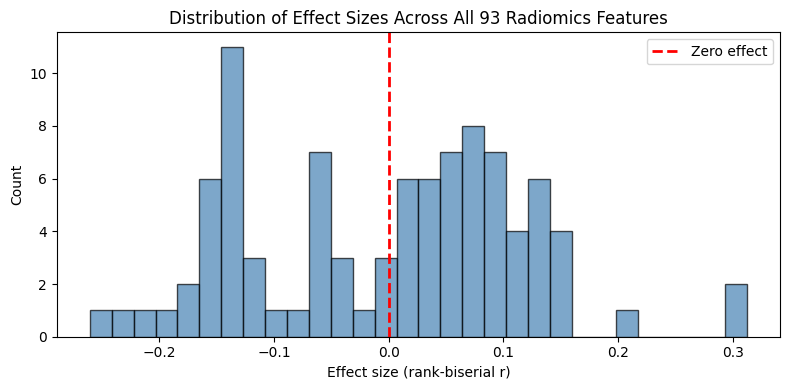

Mean effect size:   -0.0019
Median effect size: 0.0197
Range: [-0.2604, 0.3124]
Features with |r| > 0.2: 6
Features with |r| > 0.3: 2

The effect sizes cluster near zero. Even the largest effects are small.
This is consistent with the p-value results: no meaningful differences.


In [14]:
# Histogram of ALL effect sizes from our real results
effect_sizes_real = results_df["effect_size"].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(effect_sizes_real, bins=30, edgecolor="black", color="steelblue", alpha=0.7)
ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero effect")
ax.set_xlabel("Effect size (rank-biserial r)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Effect Sizes Across All 93 Radiomics Features")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean effect size:   {effect_sizes_real.mean():.4f}")
print(f"Median effect size: {np.median(effect_sizes_real):.4f}")
print(f"Range: [{effect_sizes_real.min():.4f}, {effect_sizes_real.max():.4f}]")
print(f"Features with |r| > 0.2: {np.sum(np.abs(effect_sizes_real) > 0.2)}")
print(f"Features with |r| > 0.3: {np.sum(np.abs(effect_sizes_real) > 0.3)}")
print()
print("The effect sizes cluster near zero. Even the largest effects are small.")
print("This is consistent with the p-value results: no meaningful differences.")

---
## Section 9: Why Statistical Tests Have No "Test Set"

If you come from a machine learning background, you might wonder: where is the test set? In ML, you train on some data and evaluate on held-out data. The test set proves the model generalises to new data.

**Statistical tests work differently.** You use ALL the data at once. There is no train/test split. This might feel wrong, but there is a good reason:

A statistical test is not making a prediction. It is answering a specific question: "Is this observed difference likely to have arisen by chance?" The p-value itself is the safeguard -- it quantifies the probability of the observation under the null hypothesis. No held-out data is needed for this calculation.

### The critical assumption: pre-registration

This only works if you do not "peek" at the data to decide which tests to run.

**Data dredging** (also called **p-hacking**) is when you:
1. Look at all 93 features
2. Find the one with the smallest p-value
3. Report only that p-value, as if you had only tested one feature

This is misleading because you are reporting the "winner" of 93 random trials. The p-value for that single feature does not account for the fact that you searched through 93 features to find it.

**Multiple comparisons correction** (Section 7) is the formal solution: it adjusts all 93 p-values to account for the number of tests performed.

### Connection to our project

In our analysis, we tested all 93 features, applied FDR correction, and found 0 significant features. This is a clean, honest result:
- We tested everything (no cherry-picking)
- We corrected for multiple comparisons (no inflated false positive rate)
- The answer is clear: no radiomics feature reliably distinguishes rejection from non-rejection in our data

---
## Section 10: Summary

### Key Takeaways

1. **A p-value is the probability of the data under the null hypothesis.** It answers: "How surprising is this data if there is no real effect?" It is NOT the probability that the result is wrong.

2. **Alpha = 0.05 means we accept a 5% false positive rate.** Even with no real effect, 5% of tests will come out "significant." This is by design, not a flaw.

3. **Testing many features inflates false positives.** With 93 features at alpha = 0.05, we expect about 4.65 false positives by chance alone. Correction methods (Bonferroni, Benjamini-Hochberg FDR) are essential.

4. **Effect size tells you how big the difference is.** A p-value only tells you whether the difference is unlikely to be due to chance. Cohen's d and rank-biserial r quantify the magnitude. Our radiomics features have very small effect sizes (|r| near 0).

5. **Statistical tests use all data at once.** Unlike ML, there is no train/test split. The p-value is the safeguard. But this only works if you do not cherry-pick which tests to report -- multiple comparisons correction handles this.

6. **Our radiomics features show no significant differences.** With or without correction, no feature reliably distinguishes rejection from non-rejection in our 134 pancreas ultrasound images. The effect sizes are too small for our sample sizes to detect.